<a href="https://colab.research.google.com/github/abhishekanand04/DAV---Fundamentals/blob/fundamentals/Dec24_Feature_Engineering_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kstest

import warnings
warnings.filterwarnings('ignore')

In [ ]:
!gdown 1JR9TDe1BQN9crA5n6JrL_clnNY1AhebJ

Downloading...
From: https://drive.google.com/uc?id=1JR9TDe1BQN9crA5n6JrL_clnNY1AhebJ
To: /content/updated_loan.csv
100% 67.0k/67.0k [00:00<00:00, 39.6MB/s]


In [ ]:
# read the updated data

data = pd.read_csv('/content/updated_loan.csv')
data.shape

(614, 18)

In [ ]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_bin,TotalIncome,TotalIncome_bin,Loan_Amount_per_year,EMI,Able_to_pay_EMI
0,Male,No,0,Graduate,No,5849,0.0,NaN,30.0,1.0,Urban,Y,Medium,5849.0,High,NaN,NaN,0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,30.0,1.0,Rural,N,Medium,6091.0,High,4.266667,355.555556,1
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,30.0,1.0,Urban,Y,Average,3000.0,Low,2.200000,183.333333,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,30.0,1.0,Urban,Y,Average,4941.0,Average,4.000000,333.333333,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,30.0,1.0,Urban,Y,Medium,6000.0,High,4.700000,391.666667,1


In [ ]:
data["Dependents"].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,51


In [ ]:
# replacing 3+ with 3
data['Dependents'].replace('3+',3,inplace=True)

data["Dependents"].value_counts()

,count
Dependents,
0,345
1,102
2,101
3,51


In [ ]:
data["Credit_History"].value_counts()

,count
Credit_History,
1.0,475
0.0,89


In [ ]:
# how many percentage of data is missing in each column

missing_value = pd.DataFrame({
    'Missing Value': data.isnull().sum(),
    'Percentage': (data.isnull().sum() / len(data))*100
})
missing_value.sort_values(by='Percentage', ascending=False)

,Missing Value,Percentage
Credit_History,50,8.143322
EMI,36,5.863192
Loan_Amount_per_year,36,5.863192
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599
CoapplicantIncome,0,0.000000


In [ ]:
data["Credit_History"].value_counts()

,count
Credit_History,
1.0,475
0.0,89


In [ ]:
data["Credit_History"].isna().sum()

50

In [ ]:
data.shape

(614, 18)

In [ ]:
pd.crosstab(data["Credit_History"],data["Loan_Status"])

Loan_Status,N,Y
Credit_History,,
0.0,82,7
1.0,97,378


In [ ]:
from scipy.stats import chi2_contingency

# H0: Credit history  and Loan status is independent

chi2_contingency(pd.crosstab(data['Credit_History'], data['Loan_Status']))

Chi2ContingencyResult(statistic=174.63729658142535, pvalue=7.184759548750746e-40, dof=1, expected_freq=array([[ 28.2464539,  60.7535461],
       [150.7535461, 324.2464539]]))

<Axes: xlabel='Credit_History', ylabel='count'>

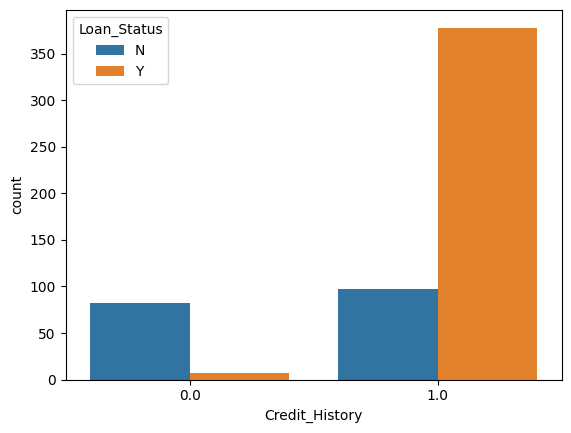

In [ ]:
sns.countplot(x= data["Credit_History"],hue=data["Loan_Status"])

In [ ]:
data["Credit_History"]=data["Credit_History"].fillna(2)
data["Credit_History"].value_counts()

,count
Credit_History,
1.0,475
0.0,89
2.0,50


In [ ]:
data["Self_Employed"].value_counts()

,count
Self_Employed,
No,500
Yes,82


In [ ]:
data["Self_Employed"].isna().sum()

32

In [ ]:
pd.crosstab(data['Self_Employed'], data['Loan_Status'])

Loan_Status,N,Y
Self_Employed,,
No,157,343
Yes,26,56


In [ ]:
chi2_contingency(pd.crosstab(data['Self_Employed'], data['Loan_Status']))

Chi2ContingencyResult(statistic=0.0, pvalue=1.0, dof=1, expected_freq=array([[157.21649485, 342.78350515],
       [ 25.78350515,  56.21649485]]))

In [ ]:
data["Self_Employed"]=data["Self_Employed"].fillna("Other")

In [ ]:
data["Self_Employed"].value_counts()

,count
Self_Employed,
No,500
Yes,82
Other,32


In [ ]:
chi2_contingency(pd.crosstab(data['Self_Employed'], data['Loan_Status']))

Chi2ContingencyResult(statistic=0.15849843135909122, pvalue=0.9238096679003514, dof=2, expected_freq=array([[156.35179153, 343.64820847],
       [ 10.00651466,  21.99348534],
       [ 25.64169381,  56.35830619]]))

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
a = pd.DataFrame([10, 10, 20, 10, 30, 10, np.nan, 50])
a

,0
0,10.0
1,10.0
2,20.0
3,10.0
4,30.0
5,10.0
6,NaN
7,50.0


In [ ]:
a.mean()

,0
0,20.0


In [ ]:
SimpleImputer(strategy="mean").fit_transform(a)

array([[10.],
       [10.],
       [20.],
       [10.],
       [30.],
       [10.],
       [20.],
       [50.]])

In [ ]:
a.mode()

,0
0,10.0


In [ ]:
SimpleImputer(strategy="most_frequent").fit_transform(a)

array([[10.],
       [10.],
       [20.],
       [10.],
       [30.],
       [10.],
       [10.],
       [50.]])

In [ ]:
SimpleImputer(strategy="constant",fill_value=1000).fit_transform(a)

array([[  10.],
       [  10.],
       [  20.],
       [  10.],
       [  30.],
       [  10.],
       [1000.],
       [  50.]])

In [ ]:
# Missing numeric columns

# set of columns
num_missing = ['EMI', 'Loan_Amount_per_year',  'LoanAmount',  'Loan_Amount_Term']

# instance of simple imputer class with a median strategy
median_imputer = SimpleImputer(strategy = 'median')

for col in num_missing:
    data[col] = pd.DataFrame(median_imputer.fit_transform(pd.DataFrame(data[col])))

In [ ]:
cat_missing = ['Gender', 'Married','Dependents']

freq_imputer = SimpleImputer(strategy = 'most_frequent') # mode
for col in cat_missing:
    data[col] = pd.DataFrame(freq_imputer.fit_transform(pd.DataFrame(data[col])))

In [ ]:
data.isna().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


<Axes: >

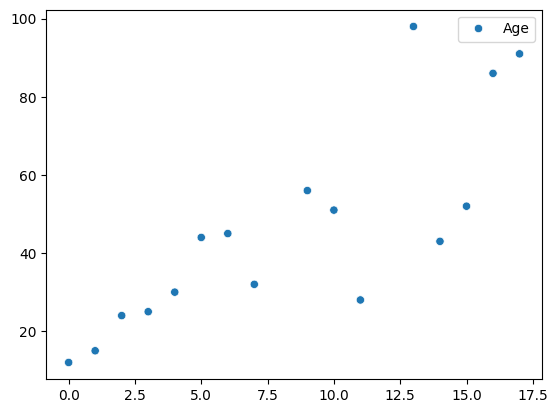

In [ ]:
from sklearn.impute import SimpleImputer
import pandas as pd
import seaborn as sns

# Assuming 'test_data' is a DataFrame with missing values in the 'Age' column
test_data = pd.DataFrame({'Age': [12, 15, 24, 25, 30, 44, 45, 32, None, 56, 51, 28, None, 98, 43, 52, 86, 91]})

sns.scatterplot(test_data)

In [ ]:
# Create a SimpleImputer with the median strategy
imputer = SimpleImputer(strategy='median')

# Fit and transform the data
test_data['Age'] = imputer.fit_transform(test_data[['Age']])

# Print the imputed data
print(test_data)

     Age
0   12.0
1   15.0
2   24.0
3   25.0
4   30.0
5   44.0
6   45.0
7   32.0
8   43.5
9   56.0
10  51.0
11  28.0
12  43.5
13  98.0
14  43.0
15  52.0
16  86.0
17  91.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gender                614 non-null    object 
 1   Married               614 non-null    object 
 2   Dependents            614 non-null    object 
 3   Education             614 non-null    object 
 4   Self_Employed         614 non-null    object 
 5   ApplicantIncome       614 non-null    int64  
 6   CoapplicantIncome     614 non-null    float64
 7   LoanAmount            614 non-null    float64
 8   Loan_Amount_Term      614 non-null    float64
 9   Credit_History        614 non-null    float64
 10  Property_Area         614 non-null    object 
 11  Loan_Status           614 non-null    object 
 12  Income_bin            614 non-null    object 
 13  TotalIncome           614 non-null    float64
 14  TotalIncome_bin       614 non-null    object 
 15  Loan_Amount_per_year  6

In [ ]:
# filter the numeric variables from the data
df_num = data.select_dtypes(include = np.number)

df_num.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'TotalIncome',
       'Loan_Amount_per_year', 'EMI', 'Able_to_pay_EMI'],
      dtype='object')

In [ ]:
df_num.drop(['Credit_History','Able_to_pay_EMI'],axis=1,inplace=True)
df_num.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,TotalIncome,Loan_Amount_per_year,EMI
0,5849,0.0,128.0,30.0,5849.0,4.383333,365.277778
1,4583,1508.0,128.0,30.0,6091.0,4.266667,355.555556
2,3000,0.0,66.0,30.0,3000.0,2.200000,183.333333
3,2583,2358.0,120.0,30.0,4941.0,4.000000,333.333333
4,6000,0.0,141.0,30.0,6000.0,4.700000,391.666667


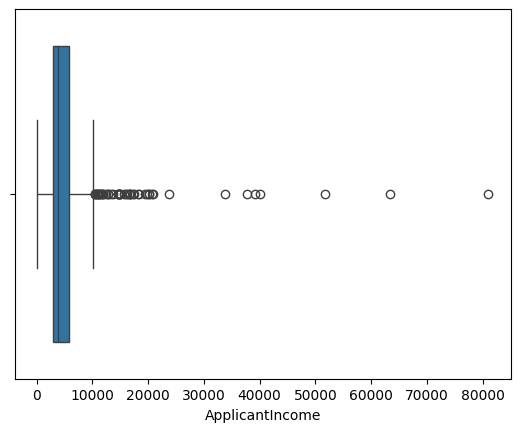

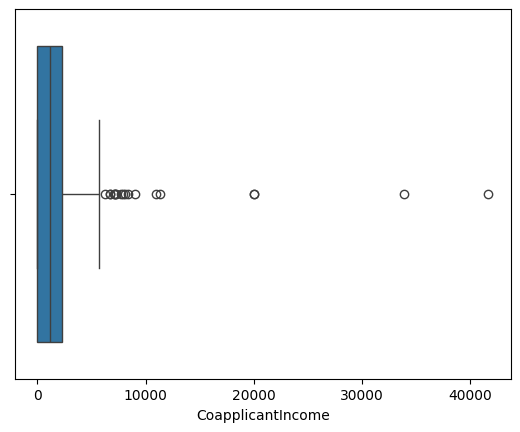

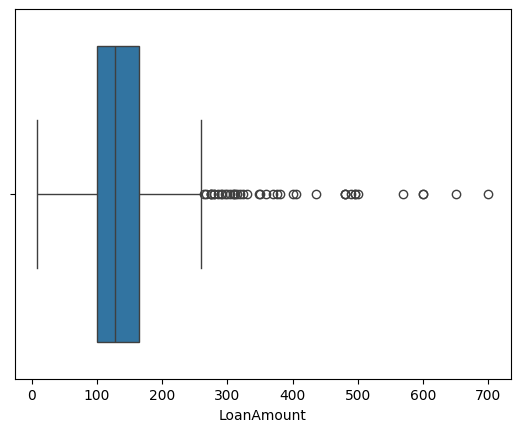

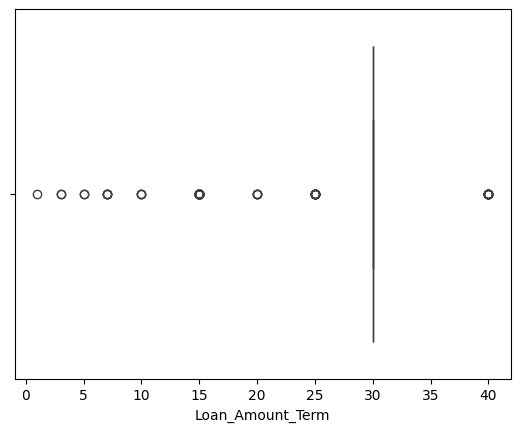

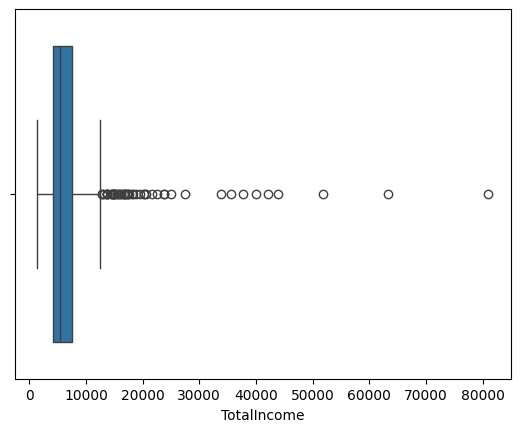

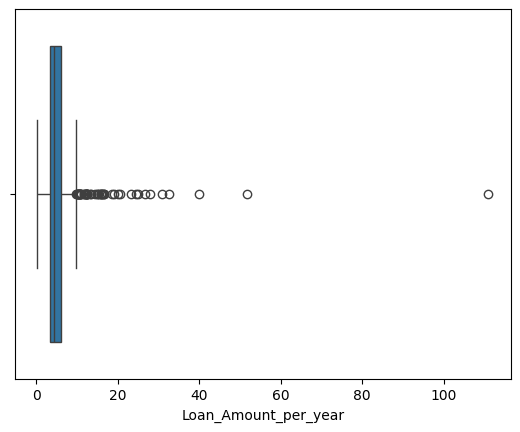

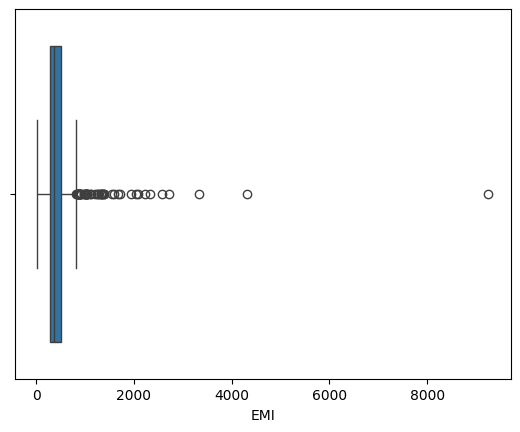

In [ ]:
for col in enumerate(df_num):
    sns.boxplot(x=col[1],data=df_num)
    plt.show()

In [ ]:
# obtain the first quartile
Q1 = df_num.quantile(0.25)

# obtain the third quartile
Q3 = df_num.quantile(0.75)

# obtain the IQR
IQR = Q3 - Q1

# print the IQR
print(IQR)

ApplicantIncome         2917.500000
CoapplicantIncome       2297.250000
LoanAmount                64.500000
Loan_Amount_Term           0.000000
TotalIncome             3355.750000
Loan_Amount_per_year       2.500000
EMI                      208.333333
dtype: float64


In [ ]:
print(Q1)

ApplicantIncome         2877.500000
CoapplicantIncome          0.000000
LoanAmount               100.250000
Loan_Amount_Term          30.000000
TotalIncome             4166.000000
Loan_Amount_per_year       3.500000
EMI                      291.666667
Name: 0.25, dtype: float64


In [ ]:
print(Q3)

ApplicantIncome         5795.00
CoapplicantIncome       2297.25
LoanAmount               164.75
Loan_Amount_Term          30.00
TotalIncome             7521.75
Loan_Amount_per_year       6.00
EMI                      500.00
Name: 0.75, dtype: float64


In [ ]:
(df_num < (Q1 - 1.5 * IQR))|(df_num > (Q3 + 1.5 * IQR))

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,TotalIncome,Loan_Amount_per_year,EMI
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
609,False,False,False,False,False,False,False
610,False,False,False,True,False,False,False
611,False,False,False,False,False,False,False
612,False,False,False,False,False,False,False


In [ ]:
# Removing outliers
df_iqr = data[~((df_num < (Q1-1.5 * IQR))|(df_num > (Q3 + 1.5 * IQR))).any(axis=1)]

In [ ]:
df_iqr.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_bin,TotalIncome,TotalIncome_bin,Loan_Amount_per_year,EMI,Able_to_pay_EMI
0,Male,No,0,Graduate,No,5849,0.0,128.0,30.0,1.0,Urban,Y,Medium,5849.0,High,4.383333,365.277778,0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,30.0,1.0,Rural,N,Medium,6091.0,High,4.266667,355.555556,1
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,30.0,1.0,Urban,Y,Average,3000.0,Low,2.200000,183.333333,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,30.0,1.0,Urban,Y,Average,4941.0,Average,4.000000,333.333333,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,30.0,1.0,Urban,Y,Medium,6000.0,High,4.700000,391.666667,1


In [ ]:
df_iqr.shape

(458, 18)

In [ ]:
import scipy
from scipy import stats

# z-scores are defined for each observation in a variable
# compute the z-scores using the method zscore from the scipy library
z_scores_LoanAmount = scipy.stats.zscore(df_num["LoanAmount"])

# display the z-scores
z_scores_LoanAmount

,LoanAmount
0,-0.211241
1,-0.211241
2,-0.948996
3,-0.306435
4,-0.056551
...,...
609,-0.889500
610,-1.258378
611,1.276168
612,0.490816


In [ ]:
# print the rows where the z-score is less than -3
row_index_less = np.where(z_scores_LoanAmount < -3)

# print the values
print(row_index_less)

(array([], dtype=int64),)


In [ ]:
# print the rows where the z-score is more than 3
row_index_more = np.where(z_scores_LoanAmount > 3)

# print the values more than the
print(row_index_more)

(array([130, 155, 171, 177, 278, 308, 333, 369, 432, 487, 506, 523, 525,
       561, 604]),)


In [ ]:
# count of outliers in the variable representing LoanAmount
len(row_index_less[0]) + len(row_index_more[0])

15

In [ ]:
# Filter out the outlier values
# ~: Select all rows which do not satisfy the condition
df_LoanAmount_zscore = data["LoanAmount"][~(( z_scores_LoanAmount < -3) |(z_scores_LoanAmount > 3))]

In [ ]:
# check the shape
df_LoanAmount_zscore.shape

(599,)

In [ ]:
data.shape

(614, 18)

In [ ]:
import numpy as np

# Given dataset
data = np.array([15, 18, 22, 23, 25, 28, 40, 75, 200])

# Calculate Q1, Q3, and IQR
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

# Determine the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = [value for value in data if value < lower_bound or value > upper_bound]

# Print the results
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Identified Outliers:", outliers)

Lower Bound: -5.0
Upper Bound: 67.0
Identified Outliers: [75, 200]


In [ ]:
# Target Encoding
!pip install --upgrade category_encoders

In [ ]:
from category_encoders import TargetEncoder

In [ ]:
pd.crosstab(df_iqr["Property_Area"], df_iqr["Loan_Status"])

Loan_Status,N,Y
Property_Area,,
Rural,52,91
Semiurban,36,142
Urban,45,92


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
col = 'Loan_Status'
label_encoder = LabelEncoder()
df_iqr[col] = label_encoder.fit_transform(df_iqr[col])
df_iqr[col].value_counts()

,count
Loan_Status,
1,325
0,133


In [ ]:
pd.crosstab(df_iqr["Property_Area"], df_iqr["Loan_Status"])

Loan_Status,0,1
Property_Area,,
Rural,52,91
Semiurban,36,142
Urban,45,92


In [ ]:
pd.crosstab(df_iqr["Property_Area"], df_iqr["Loan_Status"],normalize="index")

Loan_Status,0,1
Property_Area,,
Rural,0.363636,0.636364
Semiurban,0.202247,0.797753
Urban,0.328467,0.671533


In [ ]:
col = "Property_Area"
te = TargetEncoder()

# here I need to pass 2 things as parameters. 1st the column that I'm working on
# 2nd the Target column

df_iqr[col] = te.fit_transform(df_iqr[col], df_iqr["Loan_Status"])
df_iqr[col].value_counts()

AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [ ]:
col = "Self_Employed"
te = TargetEncoder()
df_iqr[col] = te.fit_transform(df_iqr[col], df_iqr["Loan_Status"])
df_iqr[col].value_counts()

AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [ ]:
!pip show scikit-learn category_encoders

Name: scikit-learn
Version: 1.5.2
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

Copyright (c) 2007-2024 The scikit-learn developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

* Redistributions of source code must retain the above copyright notice, this
  list of conditions and the following disclaimer.

* Redistributions in binary form must reproduce the above copyright notice,
  this list of conditions and the following disclaimer in the documentation
  and/or other materials provided with the distribution.

* Neither the name of the copyright holder nor the names of its
  contributors may be used to endorse or promote products derived from
  this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS 

In [ ]:
!pip install -U scikit-learn category-encoders